# BrushCue Example: Solarize

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/solarize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/solarize

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver '

'


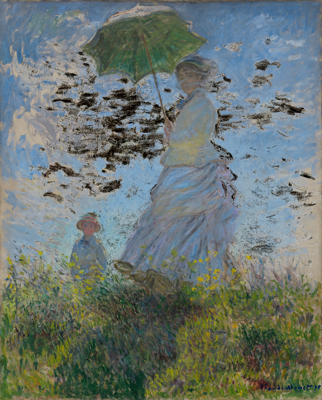

In [1]:
import io
from PIL import Image

import brushcue as bc

threshold = 0.8
graph = bc.Composition.monet_women_with_parasol().color_transformer_shader(
    "let l = input.x;\nlet new_l = select(l, 1.0 - l, l > threshold);\nreturn vec4(new_l, input.y, input.z, input.w);",
    "",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("threshold", threshold),
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
